# 📊 Bước 1: Tiền xử lý & Kết nối Dữ liệu (Data Preparation)

**Mục tiêu:** Lấy mẫu, hợp nhất và làm sạch 4 file dữ liệu KKBox thành 1 bảng thống nhất.

**Dataset gốc:**
- `train.csv` — Dữ liệu tương tác (msno, song_id, target)
- `members.csv` — Thông tin thành viên (city, bd, gender, ...)
- `songs.csv` — Thông tin bài hát (genre_ids, artist_name, language, ...)
- `song_extra_info.csv` — Tên bài hát & mã ISRC

## 1.1 Import thư viện

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Cấu hình hiển thị
plt.rcParams['font.size'] = 12
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 200)

print('✅ Import thư viện thành công!')

✅ Import thư viện thành công!


## 1.2 Load dữ liệu gốc

Đọc 4 file CSV từ folder `kkbox_dataset/`.

In [3]:
DATA_PATH = 'kkbox_dataset/'

# Load 4 file CSV
train = pd.read_csv(DATA_PATH + 'train.csv')
members = pd.read_csv(DATA_PATH + 'members.csv')
songs = pd.read_csv(DATA_PATH + 'songs.csv')
extra_info = pd.read_csv(DATA_PATH + 'song_extra_info.csv')

print('📁 Kích thước các bảng dữ liệu:')
print(f'  train.csv:           {train.shape[0]:>12,} dòng × {train.shape[1]} cột')
print(f'  members.csv:         {members.shape[0]:>12,} dòng × {members.shape[1]} cột')
print(f'  songs.csv:           {songs.shape[0]:>12,} dòng × {songs.shape[1]} cột')
print(f'  song_extra_info.csv: {extra_info.shape[0]:>12,} dòng × {extra_info.shape[1]} cột')

📁 Kích thước các bảng dữ liệu:
  train.csv:              7,377,418 dòng × 6 cột
  members.csv:               34,403 dòng × 7 cột
  songs.csv:              2,296,320 dòng × 7 cột
  song_extra_info.csv:    2,295,971 dòng × 3 cột


### 📋 Cấu trúc bảng `train.csv`

In [4]:
print('--- train.csv ---')
print(train.dtypes)
print(f'\nNull values:\n{train.isnull().sum()}')
train.head()

--- train.csv ---
msno                    str
song_id                 str
source_system_tab       str
source_screen_name      str
source_type             str
target                int64
dtype: object

Null values:
msno                       0
song_id                    0
source_system_tab      24849
source_screen_name    414804
source_type            21539
target                     0
dtype: int64


,msno,song_id,source_system_tab,source_screen_name,source_type,target
0,FGtllVqz18RPiwJj/edr2gV78zirAiY/9SmYvia+kCg=,BBzumQNXUHKdEBOB7mAJuzok+IJA1c2Ryg/yzTF6tik=,explore,Explore,online-playlist,1
1,Xumu+NIjS6QYVxDS4/t3SawvJ7viT9hPKXmf0RtLNx8=,bhp/MpSNoqoxOIB+/l8WPqu6jldth4DIpCm3ayXnJqM=,my library,Local playlist more,local-playlist,1
2,Xumu+NIjS6QYVxDS4/t3SawvJ7viT9hPKXmf0RtLNx8=,JNWfrrC7zNN7BdMpsISKa4Mw+xVJYNnxXh3/Epw7QgY=,my library,Local playlist more,local-playlist,1
3,Xumu+NIjS6QYVxDS4/t3SawvJ7viT9hPKXmf0RtLNx8=,2A87tzfnJTSWqD7gIZHisolhe4DMdzkbd6LzO1KHjNs=,my library,Local playlist more,local-playlist,1
4,FGtllVqz18RPiwJj/edr2gV78zirAiY/9SmYvia+kCg=,3qm6XTZ6MOCU11x8FIVbAGH5l5uMkT3/ZalWG1oo2Gc=,explore,Explore,online-playlist,1


### 📋 Cấu trúc bảng `members.csv`

In [5]:
print('--- members.csv ---')
print(members.dtypes)
print(f'\nNull values:\n{members.isnull().sum()}')
members.head()

--- members.csv ---
msno                        str
city                      int64
bd                        int64
gender                      str
registered_via            int64
registration_init_time    int64
expiration_date           int64
dtype: object

Null values:
msno                          0
city                          0
bd                            0
gender                    19902
registered_via                0
registration_init_time        0
expiration_date               0
dtype: int64


,msno,city,bd,gender,registered_via,registration_init_time,expiration_date
0,XQxgAYj3klVKjR3oxPPXYYFp4soD4TuBghkhMTD4oTw=,1,0,NaN,7,20110820,20170920
1,UizsfmJb9mV54qE9hCYyU07Va97c0lCRLEQX3ae+ztM=,1,0,NaN,7,20150628,20170622
2,D8nEhsIOBSoE6VthTaqDX8U6lqjJ7dLdr72mOyLya2A=,1,0,NaN,4,20160411,20170712
3,mCuD+tZ1hERA/o5GPqk38e041J8ZsBaLcu7nGoIIvhI=,1,0,NaN,9,20150906,20150907
4,q4HRBfVSssAFS9iRfxWrohxuk9kCYMKjHOEagUMV6rQ=,1,0,NaN,4,20170126,20170613


### 📋 Cấu trúc bảng `songs.csv`

In [6]:
print('--- songs.csv ---')
print(songs.dtypes)
print(f'\nNull values:\n{songs.isnull().sum()}')
songs.head()

--- songs.csv ---
song_id            str
song_length      int64
genre_ids          str
artist_name        str
composer           str
lyricist           str
language       float64
dtype: object

Null values:
song_id              0
song_length          0
genre_ids        94116
artist_name          0
composer       1071358
lyricist       1945306
language             1
dtype: int64


,song_id,song_length,genre_ids,artist_name,composer,lyricist,language
0,CXoTN1eb7AI+DntdU1vbcwGRV4SCIDxZu+YD8JP8r4E=,247640,465,張信哲 (Jeff Chang),董貞,何啟弘,3.0
1,o0kFgae9QtnYgRkVPqLJwa05zIhRlUjfF7O1tDw0ZDU=,197328,444,BLACKPINK,TEDDY| FUTURE BOUNCE| Bekuh BOOM,TEDDY,31.0
2,DwVvVurfpuz+XPuFvucclVQEyPqcpUkHR0ne1RQzPs0=,231781,465,SUPER JUNIOR,NaN,NaN,31.0
3,dKMBWoZyScdxSkihKG+Vf47nc18N9q4m58+b4e7dSSE=,273554,465,S.H.E,湯小康,徐世珍,3.0
4,W3bqWd3T+VeHFzHAUfARgW9AvVRaF4N5Yzm4Mr6Eo/o=,140329,726,貴族精選,Traditional,Traditional,52.0


### 📋 Cấu trúc bảng `song_extra_info.csv`

In [7]:
print('--- song_extra_info.csv ---')
print(extra_info.dtypes)
print(f'\nNull values:\n{extra_info.isnull().sum()}')
extra_info.head()

--- song_extra_info.csv ---
song_id    str
name       str
isrc       str
dtype: object

Null values:
song_id         0
name            3
isrc       136548
dtype: int64


,song_id,name,isrc
0,LP7pLJoJFBvyuUwvu+oLzjT+bI+UeBPURCecJsX1jjs=,我們,TWUM71200043
1,ClazTFnk6r0Bnuie44bocdNMM3rdlrq0bCGAsGUWcHE=,Let Me Love You,QMZSY1600015
2,u2ja/bZE3zhCGxvbbOB3zOoUjx27u40cf5g09UXMoKQ=,原諒我,TWA530887303
3,92Fqsy0+p6+RHe2EoLKjHahORHR1Kq1TBJoClW9v+Ts=,Classic,USSM11301446
4,0QFmz/+rJy1Q56C1DuYqT9hKKqi5TUqx0sN0IwvoHrw=,愛投羅網,TWA471306001


## 1.3 Lấy mẫu dữ liệu

Bảng `train.csv` có hơn **7 triệu dòng**, quá lớn để xử lý nhanh.

→ Lấy ngẫu nhiên **100,000 dòng** (random_state=42 để tái tạo kết quả).

In [8]:
SAMPLE_SIZE = 100_000

train_sample = train.sample(n=SAMPLE_SIZE, random_state=42)
print(f'✅ Đã lấy mẫu: {train_sample.shape[0]:,} dòng từ {train.shape[0]:,} dòng')
print(f'   Tỷ lệ: {SAMPLE_SIZE/len(train)*100:.2f}%')
print(f'\n📊 Phân phối target trong mẫu:')
print(train_sample['target'].value_counts())
print(f'\n   Tỷ lệ target=1: {train_sample["target"].mean()*100:.1f}%')

✅ Đã lấy mẫu: 100,000 dòng từ 7,377,418 dòng
   Tỷ lệ: 1.36%

📊 Phân phối target trong mẫu:
target
1    50597
0    49403
Name: count, dtype: int64

   Tỷ lệ target=1: 50.6%


## 1.4 Hợp nhất (Merge) 4 bảng

Quy trình merge:
1. `train_sample` + `members` → khớp theo `msno` (LEFT JOIN)
2. Kết quả + `songs` → khớp theo `song_id` (LEFT JOIN)
3. Kết quả + `song_extra_info` → khớp theo `song_id` (LEFT JOIN) → lấy tên bài hát

**LEFT JOIN** đảm bảo giữ lại toàn bộ dòng trong bảng train_sample.

In [9]:
# Bước 1: Merge train_sample + members (on msno)
df = train_sample.merge(members, on='msno', how='left')
print(f'Sau merge với members: {df.shape}')

# Bước 2: Merge với songs (on song_id)
df = df.merge(songs, on='song_id', how='left')
print(f'Sau merge với songs:   {df.shape}')

# Bước 3: Merge với song_extra_info (on song_id) → lấy tên bài hát
df = df.merge(extra_info[['song_id', 'name']], on='song_id', how='left')
print(f'Sau merge với extra:   {df.shape}')

# Đổi tên cột 'name' thành 'song_name' cho rõ ràng
df = df.rename(columns={'name': 'song_name'})

print(f'\n✅ Bảng hợp nhất: {df.shape[0]:,} dòng × {df.shape[1]} cột')
print(f'\n📋 Danh sách cột:')
for i, col in enumerate(df.columns, 1):
    print(f'  {i:2d}. {col}')

Sau merge với members: (100000, 12)
Sau merge với songs:   (100000, 18)
Sau merge với extra:   (100000, 19)

✅ Bảng hợp nhất: 100,000 dòng × 19 cột

📋 Danh sách cột:
   1. msno
   2. song_id
   3. source_system_tab
   4. source_screen_name
   5. source_type
   6. target
   7. city
   8. bd
   9. gender
  10. registered_via
  11. registration_init_time
  12. expiration_date
  13. song_length
  14. genre_ids
  15. artist_name
  16. composer
  17. lyricist
  18. language
  19. song_name


In [10]:
# Xem 5 dòng đầu của bảng hợp nhất
df.head()

,msno,song_id,source_system_tab,source_screen_name,source_type,target,city,bd,gender,registered_via,registration_init_time,expiration_date,song_length,genre_ids,artist_name,composer,lyricist,language,song_name
0,RGAe8+3OzXCgYYw4LkvHHfGHPW48eT57SO9tCDqF6wU=,XcLZ7BJjc6gG5RPsg7Pb5W04mvlz6jyWErLKofUvFis=,search,Search,song,0,1,0,NaN,7,20140124,20171006,215875,465,S.H. Project,NaN,NaN,52.0,Bad Girl Good Girl
1,PQfNQQon0CwOLghOAyztQYVw6yJTVgmFpJ650q/UF1s=,9t9+DPdDvWrge1ZOUlcJvLmOfnpa4NtNEVY0rBc/91I=,discover,NaN,top-hits-for-artist,1,22,21,female,3,20141102,20170617,285779,465,梁靜茹 (Fish Leong),NaN,NaN,3.0,可惜不是你
2,cd9R76nchcG1F1oyKMVN9bXXwRssofcYVckWhIWTSrY=,LAbM25XeS2X4K+HcY802+4tu3VyXbwse7mzIEOorPJY=,radio,Radio,radio,0,14,30,female,9,20060310,20170924,232060,465,Victoria Beckham,Victoria Beckham| Julie Morrison| Harvey Mason...,NaN,52.0,In Your Dreams
3,KFznvngc8H65XDu5Y1ZgitCu5DWeOKpgtVkNYw0qlq8=,3xhSUFUYmiaYUUK6gzDE0vkhxV4nPnpyZL4Z+nzU7/8=,my library,Local playlist more,local-playlist,0,11,26,female,9,20070928,20170930,250462,359,Lucia,NaN,NaN,31.0,noir 느와르
4,phnWUuC1a4M2RO/6He3Wb8Ji3Ex6QV5AQ2KCGlqpIG8=,+ZXjijLJdny/t5JIuFm4xIlM+bRYKIkaHGDcfDSKfH8=,discover,Artist more,top-hits-for-artist,1,14,0,NaN,9,20150308,20170908,231026,465,孫子涵 (Niko Sun),孫子涵,孫子涵,3.0,別對我說沒有未來


In [11]:
# Kiểm tra giá trị null sau merge
print('📊 Giá trị NULL sau khi merge:')
null_info = pd.DataFrame({
    'Null Count': df.isnull().sum(),
    'Null %': (df.isnull().sum() / len(df) * 100).round(2)
})
print(null_info[null_info['Null Count'] > 0])

📊 Giá trị NULL sau khi merge:
                    Null Count  Null %
source_system_tab          344    0.34
source_screen_name        5492    5.49
source_type                304    0.30
gender                   40016   40.02
genre_ids                 1613    1.61
composer                 22484   22.48
lyricist                 43007   43.01
language                     1    0.00
song_name                   14    0.01


## 1.5 Khám phá Dữ liệu (EDA - Exploratory Data Analysis)

Trực quan hóa phân phối các cột quan trọng để hiểu đặc điểm dữ liệu.

### 📊 Phân phối biến mục tiêu (`target`)

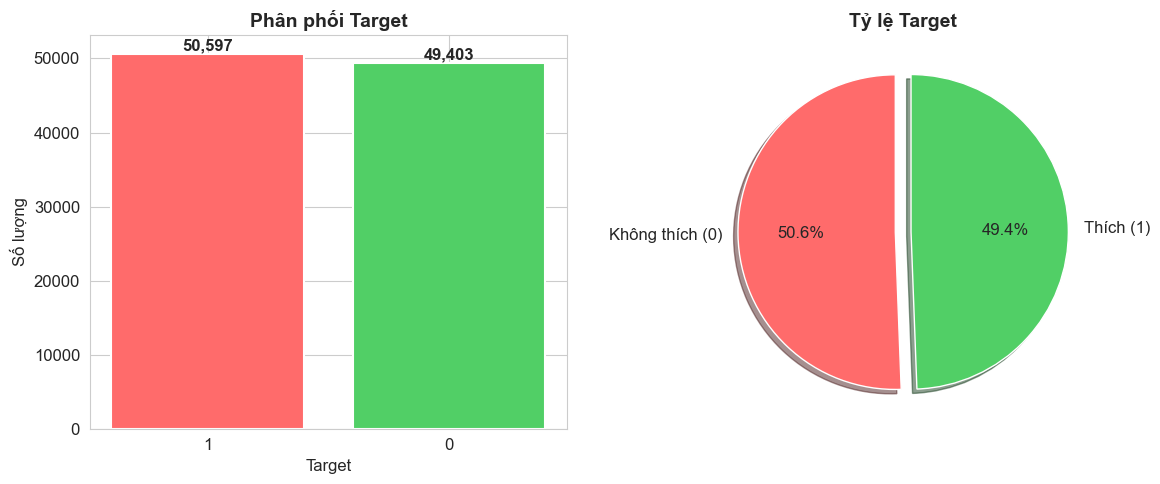

Tỷ lệ target=1 (thích): 50.6%


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Biểu đồ cột
target_counts = df['target'].value_counts()
colors = ['#ff6b6b', '#51cf66']
axes[0].bar(target_counts.index.astype(str), target_counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Phân phối Target', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Target')
axes[0].set_ylabel('Số lượng')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

# Biểu đồ tròn
axes[1].pie(target_counts.values, labels=['Không thích (0)', 'Thích (1)'],
           autopct='%1.1f%%', colors=colors, startangle=90,
           explode=(0.05, 0.05), shadow=True)
axes[1].set_title('Tỷ lệ Target', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('processed_data/eda_target.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Tỷ lệ target=1 (thích): {df["target"].mean()*100:.1f}%')

### 📊 Phân phối Tuổi (`bd`)

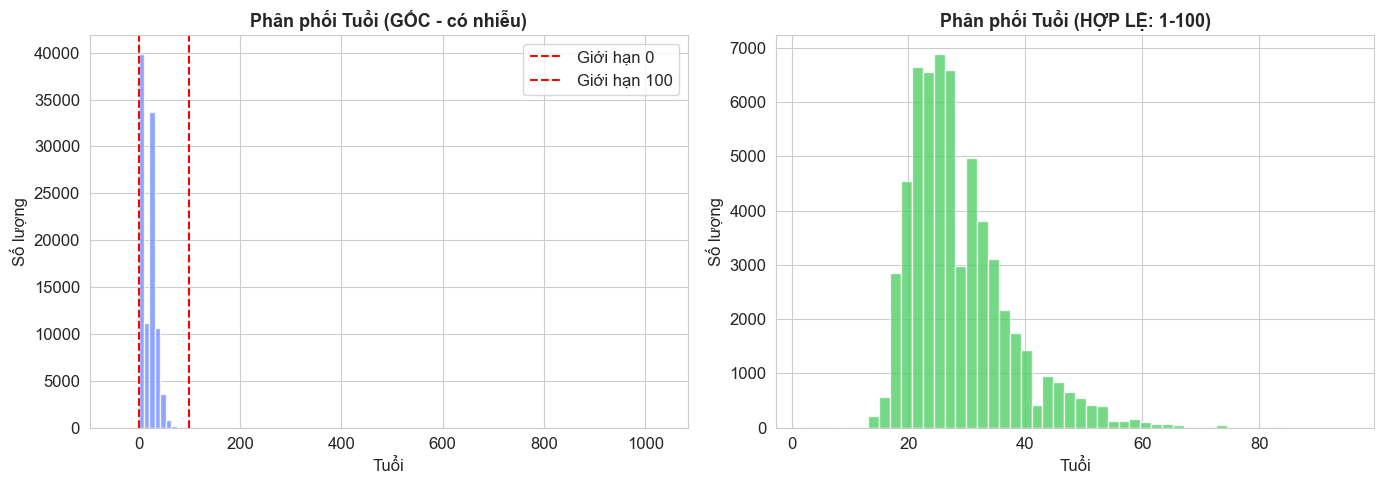

Tuổi ngoài [0, 100]: 39,913 dòng
Tuổi = 0 (thiếu):    39,826 dòng
Tuổi hợp lệ:         60,087 dòng


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram toàn bộ (bao gồm nhiễu)
axes[0].hist(df['bd'].dropna(), bins=100, color='#748ffc', edgecolor='white', alpha=0.8)
axes[0].set_title('Phân phối Tuổi (GỐC - có nhiễu)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Tuổi')
axes[0].set_ylabel('Số lượng')
axes[0].axvline(x=0, color='red', linestyle='--', label='Giới hạn 0')
axes[0].axvline(x=100, color='red', linestyle='--', label='Giới hạn 100')
axes[0].legend()

# Histogram chỉ tuổi hợp lệ
valid_age = df[(df['bd'] > 0) & (df['bd'] <= 100)]['bd']
axes[1].hist(valid_age, bins=50, color='#51cf66', edgecolor='white', alpha=0.8)
axes[1].set_title('Phân phối Tuổi (HỢP LỆ: 1-100)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Tuổi')
axes[1].set_ylabel('Số lượng')

plt.tight_layout()
plt.savefig('processed_data/eda_age.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Tuổi ngoài [0, 100]: {((df["bd"] <= 0) | (df["bd"] > 100)).sum():,} dòng')
print(f'Tuổi = 0 (thiếu):    {(df["bd"] == 0).sum():,} dòng')
print(f'Tuổi hợp lệ:         {len(valid_age):,} dòng')

### 📊 Phân phối Giới tính (`gender`) & Thành phố (`city`)

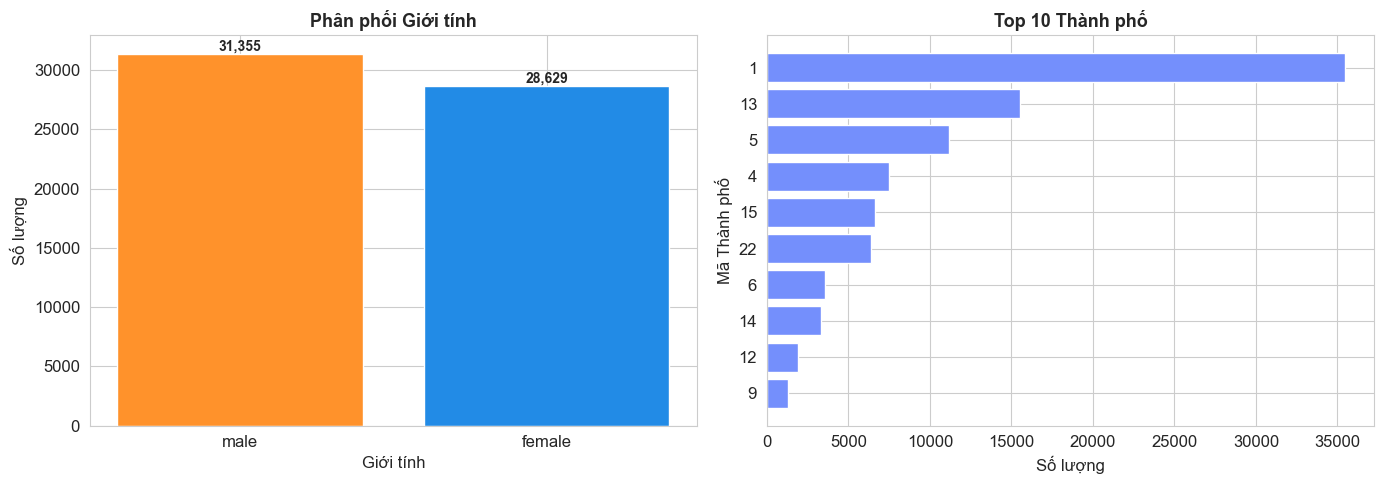

Gender NULL: 40,016 dòng (40.0%)


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gender
gender_counts = df['gender'].value_counts()
colors_g = ['#ff922b', '#228be6', '#adb5bd']
axes[0].bar(gender_counts.index.astype(str), gender_counts.values, color=colors_g[:len(gender_counts)])
axes[0].set_title('Phân phối Giới tính', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Giới tính')
axes[0].set_ylabel('Số lượng')
for i, v in enumerate(gender_counts.values):
    axes[0].text(i, v + 300, f'{v:,}', ha='center', fontweight='bold', fontsize=10)

# City (top 10)
city_counts = df['city'].value_counts().head(10)
axes[1].barh(city_counts.index.astype(str), city_counts.values, color='#748ffc')
axes[1].set_title('Top 10 Thành phố', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Số lượng')
axes[1].set_ylabel('Mã Thành phố')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('processed_data/eda_gender_city.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Gender NULL: {df["gender"].isnull().sum():,} dòng ({df["gender"].isnull().mean()*100:.1f}%)')

### 📊 Phân phối Thể loại (`genre_ids`) & Ngôn ngữ (`language`)

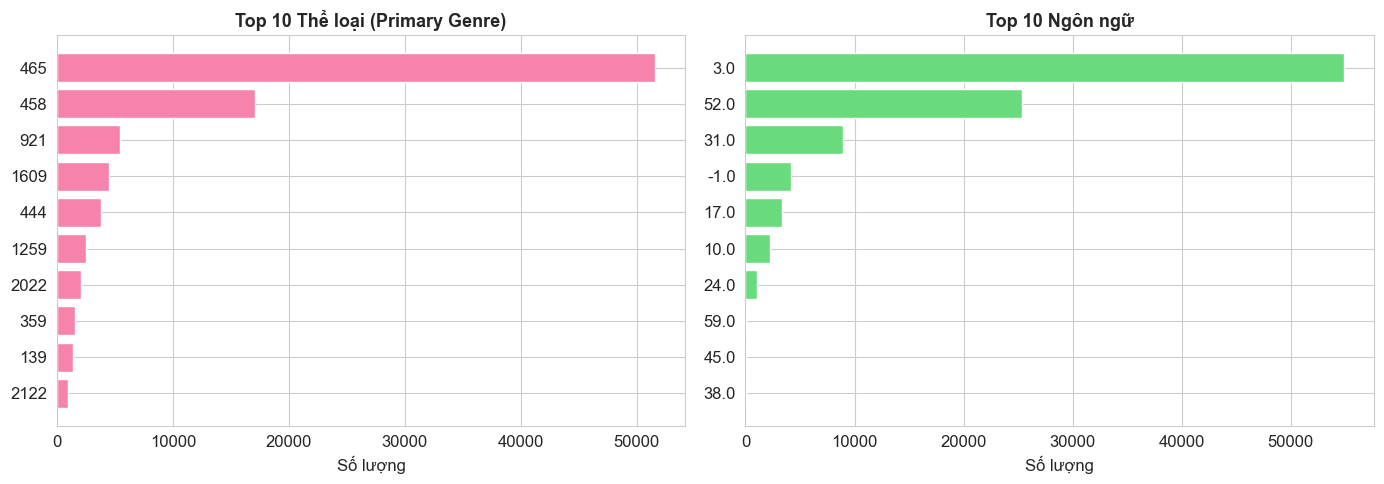

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Genre - lấy genre đầu tiên (nhiều bài có multi-genre dạng '465|444')
df['primary_genre'] = df['genre_ids'].astype(str).str.split('|').str[0]
genre_counts = df['primary_genre'].value_counts().head(10)
axes[0].barh(genre_counts.index, genre_counts.values, color='#f783ac')
axes[0].set_title('Top 10 Thể loại (Primary Genre)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Số lượng')
axes[0].invert_yaxis()

# Language
lang_counts = df['language'].value_counts().head(10)
axes[1].barh(lang_counts.index.astype(str), lang_counts.values, color='#69db7c')
axes[1].set_title('Top 10 Ngôn ngữ', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Số lượng')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('processed_data/eda_genre_language.png', dpi=150, bbox_inches='tight')
plt.show()

### 📊 Phân phối Phương thức đăng ký (`registered_via`) & Nguồn phát (`source_type`)

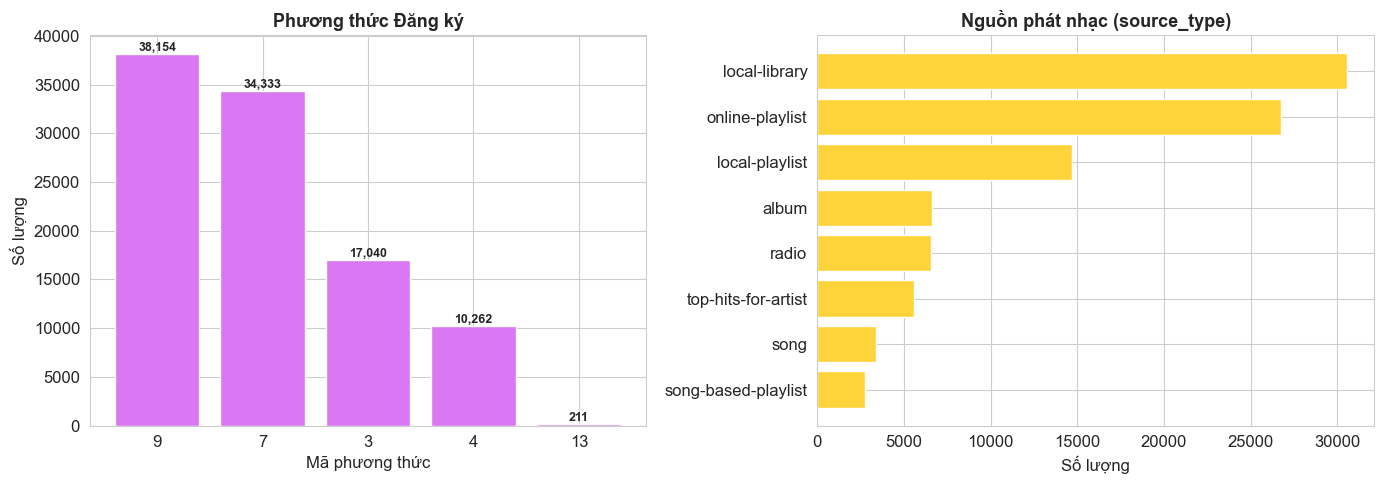

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Registered via
reg_counts = df['registered_via'].value_counts()
axes[0].bar(reg_counts.index.astype(str), reg_counts.values, color='#da77f2')
axes[0].set_title('Phương thức Đăng ký', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Mã phương thức')
axes[0].set_ylabel('Số lượng')
for i, (idx, v) in enumerate(zip(reg_counts.index, reg_counts.values)):
    axes[0].text(i, v + 300, f'{v:,}', ha='center', fontweight='bold', fontsize=9)

# Source type
src_counts = df['source_type'].value_counts().head(8)
axes[1].barh(src_counts.index.astype(str), src_counts.values, color='#ffd43b')
axes[1].set_title('Nguồn phát nhạc (source_type)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Số lượng')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('processed_data/eda_regvia_source.png', dpi=150, bbox_inches='tight')
plt.show()

## 1.6 Xử lý Dữ liệu Nhiễu (Data Cleaning)

Các vấn đề cần xử lý:
1. **`bd` (tuổi):** Giá trị ≤ 0 hoặc > 100 → thay bằng NaN → điền **median** tuổi hợp lệ
2. **`gender`:** Giá trị thiếu → điền **mode** (giá trị phổ biến nhất)
3. **`genre_ids`, `language`:** Giá trị thiếu → điền **mode**
4. **`source_system_tab`, `source_screen_name`, `source_type`:** Thiếu → điền `"unknown"`
5. **`song_name`, `composer`, `lyricist`:** Thiếu → điền `"Unknown"`

In [17]:
print('=== TRƯỚC KHI XỬ LÝ ===')
print(f'Null tổng: {df.isnull().sum().sum():,}')
print()

# 1. Xử lý cột bd (tuổi)
invalid_age = (df['bd'] <= 0) | (df['bd'] > 100)
print(f'[bd] Giá trị ngoài [1, 100]: {invalid_age.sum():,} dòng')
df.loc[invalid_age, 'bd'] = np.nan
median_age = df['bd'].median()
df['bd'] = df['bd'].fillna(median_age).astype(int)
print(f'[bd] Đã điền median = {median_age:.0f}')

# 2. Xử lý cột gender
print(f'\n[gender] Null: {df["gender"].isnull().sum():,} dòng')
df['gender'] = df['gender'].fillna(df['gender'].mode()[0])
print(f'[gender] Đã điền mode = {df["gender"].mode()[0]}')

# 3. Xử lý genre_ids, language
for col in ['genre_ids', 'language']:
    null_count = df[col].isnull().sum()
    if null_count > 0:
        mode_val = df[col].mode()[0]
        df[col] = df[col].fillna(mode_val)
        print(f'\n[{col}] Null: {null_count:,} → điền mode = {mode_val}')

# 4. Xử lý source_*
for col in ['source_system_tab', 'source_screen_name', 'source_type']:
    null_count = df[col].isnull().sum()
    if null_count > 0:
        df[col] = df[col].fillna('unknown')
        print(f'[{col}] Null: {null_count:,} → điền "unknown"')

# 5. Xử lý song_name, composer, lyricist
for col in ['song_name', 'composer', 'lyricist']:
    null_count = df[col].isnull().sum()
    if null_count > 0:
        df[col] = df[col].fillna('Unknown')
        print(f'[{col}] Null: {null_count:,} → điền "Unknown"')

# Xóa cột tạm primary_genre
if 'primary_genre' in df.columns:
    df = df.drop(columns=['primary_genre'])

=== TRƯỚC KHI XỬ LÝ ===
Null tổng: 114,888

[bd] Giá trị ngoài [1, 100]: 39,913 dòng
[bd] Đã điền median = 27

[gender] Null: 40,016 dòng
[gender] Đã điền mode = male

[genre_ids] Null: 1,613 → điền mode = 465

[language] Null: 1 → điền mode = 3.0
[source_system_tab] Null: 344 → điền "unknown"
[source_screen_name] Null: 5,492 → điền "unknown"
[source_type] Null: 304 → điền "unknown"
[song_name] Null: 14 → điền "Unknown"
[composer] Null: 22,484 → điền "Unknown"
[lyricist] Null: 43,007 → điền "Unknown"


In [ ]:
# Kiểm tra lại sau xử lý
print('=== SAU KHI XỬ LÝ ===')
print(f'Null tổng: {df.isnull().sum().sum()}')
print()
print(df.isnull().sum())
print(f'\n✅ Dữ liệu đã sạch!')

## 1.7 Lưu kết quả & Tổng kết

In [18]:
# Lưu bảng hợp nhất đã làm sạch
output_path = 'processed_data/merged_data.csv'
df.to_csv(output_path, index=False, encoding='utf-8-sig')
print(f'💾 Đã lưu: {output_path}')
print(f'   Kích thước: {df.shape[0]:,} dòng × {df.shape[1]} cột')

print(f'\n📊 TỔNG KẾT:')
print(f'   Số user (msno) duy nhất:     {df["msno"].nunique():,}')
print(f'   Số bài hát (song_id) duy nhất: {df["song_id"].nunique():,}')
print(f'   Tỷ lệ target=1 (thích):      {df["target"].mean()*100:.1f}%')
print(f'   Tỷ lệ target=0 (không thích): {(1-df["target"].mean())*100:.1f}%')
print(f'\n📋 Các cột trong bảng hợp nhất:')
for i, col in enumerate(df.columns, 1):
    print(f'   {i:2d}. {col} ({df[col].dtype})')

💾 Đã lưu: processed_data/merged_data.csv
   Kích thước: 100,000 dòng × 19 cột

📊 TỔNG KẾT:
   Số user (msno) duy nhất:     20,266
   Số bài hát (song_id) duy nhất: 33,448
   Tỷ lệ target=1 (thích):      50.6%
   Tỷ lệ target=0 (không thích): 49.4%

📋 Các cột trong bảng hợp nhất:
    1. msno (str)
    2. song_id (str)
    3. source_system_tab (str)
    4. source_screen_name (str)
    5. source_type (str)
    6. target (int64)
    7. city (int64)
    8. bd (int64)
    9. gender (str)
   10. registered_via (int64)
   11. registration_init_time (int64)
   12. expiration_date (int64)
   13. song_length (int64)
   14. genre_ids (str)
   15. artist_name (str)
   16. composer (str)
   17. lyricist (str)
   18. language (float64)
   19. song_name (str)


In [19]:
# Xem 10 dòng mẫu cuối cùng
df[['song_name', 'artist_name', 'genre_ids', 'language', 'target']].sample(10, random_state=42)

,song_name,artist_name,genre_ids,language,target
75721,Mirrors,Justin Timberlake,465,52.0,1
80184,出神入化,飛輪海 (Fahrenheit),465,3.0,1
19864,愛第三次,蕭亞軒 (Elva Hsiao),465,3.0,1
76699,Livin' On A Prayer,Bon Jovi,465|2022,52.0,0
92991,不搭,李榮浩,465,3.0,1
76434,夢醒了,那英,465,3.0,1
84004,Reignite (Knox Brown x Gallant),Various Artists,1259,52.0,1
80917,Excuse Me,AOA,444,31.0,1
60767,Dream of girl doll,Hitoshizuku|Yama (ひとしずく×やま△),465,17.0,1
50074,聽說愛情回來過,Various Artists,465,3.0,0
